# Task 1: Practical Assignment — End-to-End Linear Regression Workflow

**Objective:** Build a complete end-to-end machine learning workflow using a practical dataset (Study Hours vs. Exam Score) following standard data science lifecycle stages:
1. Data Collection / Creation
2. Data Cleaning & Inspection
3. Exploratory Data Analysis (EDA)
4. Train-Test Split
5. Model Training (Linear Regression)
6. Model Evaluation (MAE, MSE, $R^2$ Score)
7. Inference / Predictions
8. Key Takeaways

---

## 1. Import Required Libraries
We import standard libraries for data handling, visualization, and machine learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


---

## 2. Dataset Creation & Loading
We create a realistic dataset mapping student study hours to final examination scores.

In [3]:
# Creating practical tabular dataset
data = {
    'Student_ID': list(range(101, 126)),
    'Hours_Studied': [1.5, 2.0, 2.5, 2.7, 3.2, 3.5, 4.0, 4.2, 4.8, 5.0, 
                      5.1, 5.5, 6.0, 6.2, 6.8, 7.0, 7.4, 7.8, 8.0, 8.3, 
                      8.5, 8.8, 9.0, 9.2, 9.5],
    'Previous_Score': [45, 50, 48, 55, 60, 58, 62, 65, 68, 70,
                       72, 71, 75, 78, 80, 82, 85, 84, 88, 87,
                       90, 92, 91, 95, 94],
    'Exam_Score': [48, 52, 54, 58, 61, 63, 67, 69, 72, 75,
                   74, 78, 82, 81, 86, 88, 90, 92, 93, 94,
                   95, 97, 96, 99, 98]
}

df = pd.DataFrame(data)
df.head()

,Student_ID,Hours_Studied,Previous_Score,Exam_Score
0,101,1.5,45,48
1,102,2.0,50,52
2,103,2.5,48,54
3,104,2.7,55,58
4,105,3.2,60,61


---

## 3. Data Cleaning & Inspection
Verify data integrity by checking shapes, null values, and summary statistics.

In [4]:
# Inspect shape and data types
print("Dataset Shape:", df.shape)
print("\n--- Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
df.describe()

Dataset Shape: (25, 4)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      25 non-null     int64  
 1   Hours_Studied   25 non-null     float64
 2   Previous_Score  25 non-null     int64  
 3   Exam_Score      25 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 928.0 bytes

--- Missing Values ---
Student_ID        0
Hours_Studied     0
Previous_Score    0
Exam_Score        0
dtype: int64

--- Statistical Summary ---


,Student_ID,Hours_Studied,Previous_Score,Exam_Score
count,25.000000,25.000000,25.000000,25.00000
mean,113.000000,5.860000,73.800000,78.48000
std,7.359801,2.462045,15.286159,16.00552
min,101.000000,1.500000,45.000000,48.00000
25%,107.000000,4.000000,62.000000,67.00000
50%,113.000000,6.000000,75.000000,81.00000
75%,119.000000,8.000000,87.000000,93.00000
max,125.000000,9.500000,95.000000,99.00000


---

## 4. Exploratory Data Analysis (EDA)
Analyze the relationship between `Hours_Studied` and `Exam_Score`.

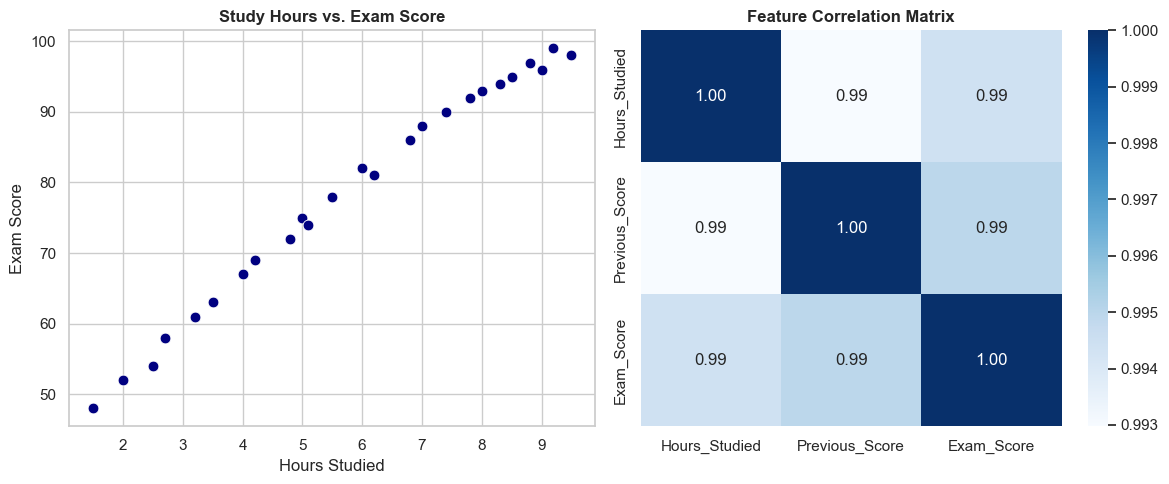

In [5]:
plt.figure(figsize=(12, 5))

# Subplot 1: Scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, color='navy', s=60)
plt.title('Study Hours vs. Exam Score', fontsize=12, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

# Subplot 2: Correlation Heatmap
plt.subplot(1, 2, 2)
corr = df[['Hours_Studied', 'Previous_Score', 'Exam_Score']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", cbar=True)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** There is a very strong positive linear correlation ($r \approx 0.99$) between hours studied and final score.

---

## 5. Feature Selection & Train-Test Split
Separate the feature matrix ($X$) from the target vector ($y$) and divide into 80% train and 20% test subsets.

In [6]:
# Defining feature matrix X and target y
X = df[['Hours_Studied']]
y = df['Exam_Score']

# Splitting into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (20, 1)
Testing set shape:  (5, 1)


---

## 6. Model Training
Fit a Linear Regression model to find the best-fit line: $y = mx + c$.

In [7]:
# Initialize and fit model
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Model Trained Successfully!")
print(f"Slope (m / Coefficient): {slope:.4f}")
print(f"Intercept (c):           {intercept:.4f}")
print(f"Equation: Exam_Score = {slope:.2f} * Hours_Studied + {intercept:.2f}")

Model Trained Successfully!
Slope (m / Coefficient): 6.3952
Intercept (c):           40.9861
Equation: Exam_Score = 6.40 * Hours_Studied + 40.99


---

## 7. Model Evaluation
Predict outcomes on the unseen test set and evaluate performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and $R^2$ Score.

In [8]:
# Predictions on test set
y_pred = model.predict(X_test)

# Metrics calculation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Comparison DataFrame
eval_df = pd.DataFrame({
    'Hours': X_test['Hours_Studied'].values,
    'Actual_Score': y_test.values,
    'Predicted_Score': np.round(y_pred, 2),
    'Error (Residual)': np.round(y_test.values - y_pred, 2)
})

print("--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE):  {mse:.3f}")
print(f"Root Mean Squared Error:   {rmse:.3f}")
print(f"R-squared Score (R²):      {r2:.4f}")
print("\n--- Actual vs Predicted Samples ---")
eval_df

--- Evaluation Metrics ---
Mean Absolute Error (MAE): 1.449
Mean Squared Error (MSE):  2.733
Root Mean Squared Error:   1.653
R-squared Score (R²):      0.9910

--- Actual vs Predicted Samples ---


,Hours,Actual_Score,Predicted_Score,Error (Residual)
0,4.8,72,71.68,0.32
1,7.4,90,88.31,1.69
2,1.5,48,50.58,-2.58
3,9.2,99,99.82,-0.82
4,5.5,78,76.16,1.84


### Regression Line Visualization

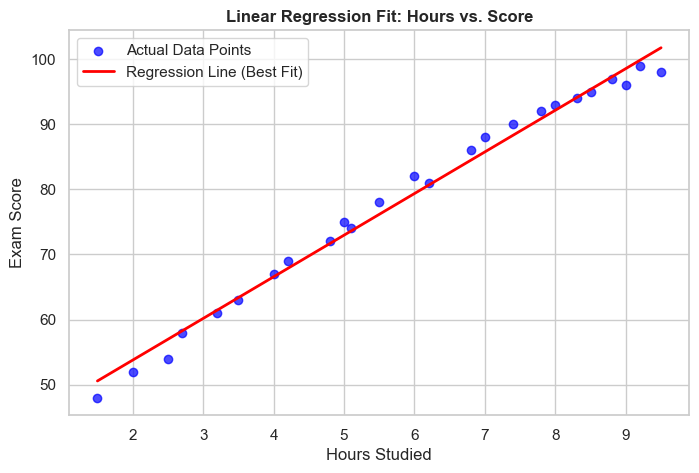

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data Points', alpha=0.7)
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line (Best Fit)')
plt.title('Linear Regression Fit: Hours vs. Score', fontsize=12, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

---

## 8. Real-world Inference (Custom Prediction)
Predict scores for new students based on arbitrary study hours.

In [10]:
custom_hours = [[3.0], [6.5], [9.8]]
custom_preds = model.predict(custom_hours)

for hours, pred in zip(custom_hours, custom_preds):
    print(f"Studying {hours[0]} hours/day -> Predicted Exam Score: {pred:.2f}")

Studying 3.0 hours/day -> Predicted Exam Score: 60.17
Studying 6.5 hours/day -> Predicted Exam Score: 82.56
Studying 9.8 hours/day -> Predicted Exam Score: 103.66


e:\programming\Machine-Learning-Engineer-Internship\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---

## 9. Conclusion & Summary
- **Data Relationship:** A clear linear trend exists between study hours and exam performance.
- **Model Performance:** High $R^2$ score indicates that the linear regression model explains virtually all the variance in the test set.
- **Practical Value:** Demonstrates how simple tabular datasets can be analyzed, cleaned, modeled, and evaluated systematically in Python.